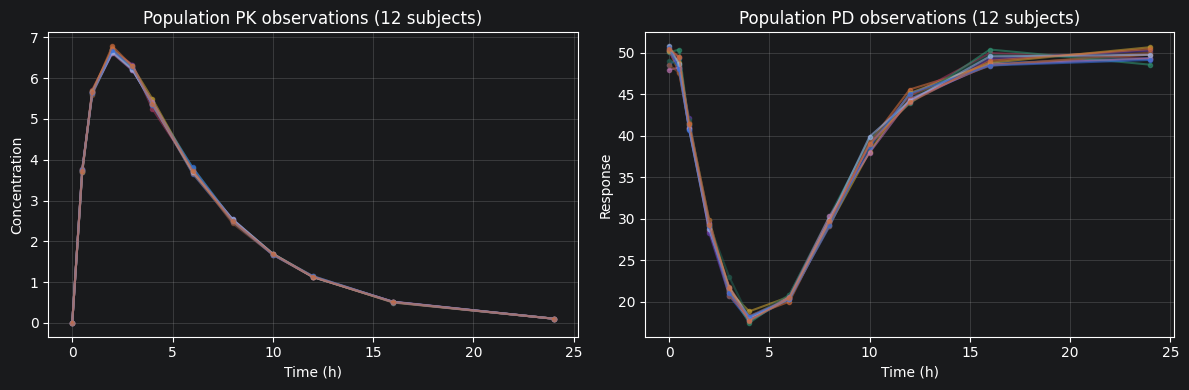

Population data ready.
pop_data shape = (144, 4)  (rows = 12 * 12)
X shape = torch.Size([144, 1]), Y shape = torch.Size([144, 1]), C_known shape = torch.Size([144, 1]), ID shape = torch.Size([144, 1])

Typical PD params (TV): {'Kin': 25.0, 'Kout': 0.5, 'Imax': 1.0, 'EC50': 4.0, 'gamma': 3.0}
First 3 sampled individual PD params:
  ID 0: Kin=25.000, Kout=0.500, Imax=1.000, EC50=4.000, gamma=3.000
  ID 1: Kin=25.000, Kout=0.500, Imax=1.000, EC50=4.000, gamma=3.000
  ID 2: Kin=25.000, Kout=0.500, Imax=1.000, EC50=4.000, gamma=3.000


In [10]:
# ============================
# Cell 1 (Population): 导入包 + 生成群体 PK/PD 数据（12个体）
# ============================
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.interpolate import interp1d

# 可复现
np.random.seed(42)
torch.manual_seed(42)

# ----------------------------
# 0) 全局设定
# ----------------------------
n_subjects = 12
t_dense = np.linspace(0, 24, 241)  # 用于数值解真值
t_obs = np.array([0, 0.5, 1, 2, 3, 4, 6, 8, 10, 12, 16, 24], dtype=float)

# PK 典型值（可视作已知机制）
tv_pk = dict(D=100.0, V=10.0, ka=1.0, ke=0.2, F=1.0)

# PD 典型值（我们希望后续识别）
tv_pd = dict(Kin=25.0, Kout=0.5, Imax=1.0, EC50=4.0, gamma=3.0)

# IIV（对数正态）标准差，表示 exp(eta), eta~N(0, omega^2)
# 可按需要调整
omega = dict(
    V=0.00, ka=0.00, ke=0.00,
    Kin=0.00, Kout=0.00, Imax=0.00, EC50=0.00
)

# 残差噪声水平
pd_noise_cv = 0.02   # 先用较小噪声
pk_noise_cv = 0.01

# ----------------------------
# 1) 个体参数采样函数
# ----------------------------
def sample_individual_params(tv_pk, tv_pd, omega):
    p = {}
    # PK
    p["D"] = tv_pk["D"]   # 剂量通常固定
    p["F"] = tv_pk["F"]
    p["V"]  = tv_pk["V"]  * np.exp(np.random.normal(0, omega["V"]))
    p["ka"] = tv_pk["ka"] * np.exp(np.random.normal(0, omega["ka"]))
    p["ke"] = tv_pk["ke"] * np.exp(np.random.normal(0, omega["ke"]))

    # 避免 ka≈ke 数值不稳定
    if abs(p["ka"] - p["ke"]) < 1e-3:
        p["ka"] = p["ke"] + 1e-3

    # PD
    p["Kin"]  = tv_pd["Kin"]  * np.exp(np.random.normal(0, omega["Kin"]))
    p["Kout"] = tv_pd["Kout"] * np.exp(np.random.normal(0, omega["Kout"]))
    p["Imax"] = tv_pd["Imax"] * np.exp(np.random.normal(0, omega["Imax"]))
    p["EC50"] = tv_pd["EC50"] * np.exp(np.random.normal(0, omega["EC50"]))
    p["gamma"] = tv_pd["gamma"]  # 先固定

    # 约束到合理范围
    p["Imax"] = np.clip(p["Imax"], 0.05, 1.5)
    p["EC50"] = max(p["EC50"], 1e-3)
    p["Kout"] = max(p["Kout"], 1e-4)
    p["Kin"]  = max(p["Kin"], 1e-4)
    return p

# ----------------------------
# 2) 用个体参数生成 C(t), R(t)
# ----------------------------
all_rows = []          # 每行: [ID, t, C_obs, R_obs]
subject_params = []    # 保存真实个体参数，后面评估用

for sid in range(n_subjects):
    p = sample_individual_params(tv_pk, tv_pd, omega)
    subject_params.append(p)

    # PK: Bateman
    pre = (p["F"] * p["D"] * p["ka"]) / (p["V"] * (p["ka"] - p["ke"]))
    C_dense = pre * (np.exp(-p["ke"] * t_dense) - np.exp(-p["ka"] * t_dense))
    C_dense = np.clip(C_dense, 0.0, None)
    C_func = interp1d(t_dense, C_dense, kind="cubic", fill_value="extrapolate")

    # PD ODE
    def pd_ode(R, t):
        C_t = max(float(C_func(t)), 1e-8)
        hill = (C_t**p["gamma"]) / (p["EC50"]**p["gamma"] + C_t**p["gamma"])
        return p["Kin"] - (p["Kin"] * p["Imax"]) * hill - p["Kout"] * R

    R0 = p["Kin"] / p["Kout"]  # 个体基线
    R_dense = odeint(lambda r, tt: pd_ode(r, tt), R0, t_dense).flatten()

    # 观测点
    C_obs_clean = C_func(t_obs)
    R_obs_clean = interp1d(t_dense, R_dense, kind="cubic")(t_obs)

    # 加噪声（比例噪声）
    C_obs = C_obs_clean * (1.0 + np.random.normal(0, pk_noise_cv, size=t_obs.shape))
    R_obs = R_obs_clean * (1.0 + np.random.normal(0, pd_noise_cv, size=t_obs.shape))

    C_obs = np.clip(C_obs, 0.0, None)

    for j, tt in enumerate(t_obs):
        all_rows.append([sid, tt, C_obs[j], R_obs[j]])

pop_data = np.array(all_rows, dtype=float)  # [N,4], N=12*12=144

# ----------------------------
# 3) 组装训练变量（先按你后面最小改造需求）
# ----------------------------
# 注意：目前先不加个体ID到网络输入，先做“pooled”版本
# X: time, Y: response, C_known: concentration (known input for library)
X_np = pop_data[:, 1:2]        # time
C_obs_np = pop_data[:, 2:3]    # observed C
Y_np = pop_data[:, 3:4]        # observed R
ID_np = pop_data[:, 0:1].astype(int)

X = torch.tensor(X_np, dtype=torch.float32)
Y = torch.tensor(Y_np, dtype=torch.float32)
C_known = torch.tensor(C_obs_np, dtype=torch.float32)
ID_tensor = torch.tensor(ID_np, dtype=torch.long)

# ----------------------------
# 4) 可视化
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for sid in range(n_subjects):
    idx = (ID_np[:, 0] == sid)
    axes[0].plot(X_np[idx, 0], C_obs_np[idx, 0], '.-', alpha=0.6)
    axes[1].plot(X_np[idx, 0], Y_np[idx, 0], '.-', alpha=0.6)

axes[0].set_title(f"Population PK observations ({n_subjects} subjects)")
axes[0].set_xlabel("Time (h)")
axes[0].set_ylabel("Concentration")
axes[0].grid(alpha=0.3)

axes[1].set_title(f"Population PD observations ({n_subjects} subjects)")
axes[1].set_xlabel("Time (h)")
axes[1].set_ylabel("Response")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Population data ready.")
print(f"pop_data shape = {pop_data.shape}  (rows = {n_subjects} * {len(t_obs)})")
print(f"X shape = {X.shape}, Y shape = {Y.shape}, C_known shape = {C_known.shape}, ID shape = {ID_tensor.shape}")

print("\nTypical PD params (TV):", tv_pd)
print("First 3 sampled individual PD params:")
for i in range(min(3, n_subjects)):
    p = subject_params[i]
    print(f"  ID {i}: Kin={p['Kin']:.3f}, Kout={p['Kout']:.3f}, Imax={p['Imax']:.3f}, EC50={p['EC50']:.3f}, gamma={p['gamma']:.3f}")

In [11]:
# ============================
# Cell 2 : DeePyMoD数据封装 + 最小PD库
# Theta = [1, Hill(C), R]
# ============================
import torch
import torch.nn as nn
from torch.autograd import grad
from typing import Tuple

from deepymod import Library
from deepymod.data import Dataset, get_train_test_loader
from deepymod.utils.types import TensorList

# ---- 1) 手动标准化 ----
x_mean, x_std = X.mean(), X.std()
y_mean, y_std = Y.mean(), Y.std()

Xn = (X - x_mean) / (x_std + 1e-8)
Yn = (Y - y_mean) / (y_std + 1e-8)

# C 不做 z-score，保留原始物理浓度
C_raw = C_known.clone()

print("Normalized tensors:")
print(f"Xn: mean={Xn.mean().item():.4f}, std={Xn.std().item():.4f}")
print(f"Yn: mean={Yn.mean().item():.4f}, std={Yn.std().item():.4f}")
print(f"C_raw: min={C_raw.min().item():.4f}, max={C_raw.max().item():.4f}")

# ---- 2) Dataset ----
def load_population_data_for_deepymod():
    return Xn.float(), Yn.float()

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

dataset = Dataset(
    load_population_data_for_deepymod,
    preprocess_kwargs={
        "noise_level": 0.0,
        "normalize_coords": False,
        "normalize_data": False,
    },
    device=device
)
train_loader, test_loader = get_train_test_loader(dataset, train_test_split=0.8)

# ---- 3) Known C(t) 模块（按时间最近邻匹配）----
class KnownCFromTime(nn.Module):
    def __init__(self, Xn_ref: torch.Tensor, Cn_ref: torch.Tensor):
        super().__init__()
        self.register_buffer("Xref", Xn_ref.detach().clone())  # [N,1]
        self.register_buffer("Cref", Cn_ref.detach().clone())  # [N,1]

    def forward(self, x_query: torch.Tensor):
        # x_query [B,1], Xref [N,1]
        dist = torch.abs(x_query - self.Xref.T)  # [B,N]
        idx = torch.argmin(dist, dim=1)          # [B]
        c = self.Cref[idx]                       # [B,1]
        return c

known_c_module = KnownCFromTime(Xn.to(device), C_raw.to(device)).to(device)

# ---- 4) 最小PD库 ----
class PDLibraryMinimal(Library):
    def __init__(self, known_c: nn.Module):
        super().__init__()
        self.known_c = known_c
        # 用更接近真值的初始化更稳
        self.raw_ec50 = nn.Parameter(torch.tensor(4.0))  # softplus(4)≈4.018
        self.raw_gamma = nn.Parameter(torch.tensor(2.5)) # softplus(2.5)≈2.58

    def library(self, input):
        prediction, data = input
        R = prediction[:, 0:1]

        dRdt = grad(
            R, data,
            grad_outputs=torch.ones_like(R),
            create_graph=True,
            retain_graph=True
        )[0][:, 0:1]

        C = self.known_c(data).clamp_min(1e-8)  # 物理浓度域
        ec50 = torch.nn.functional.softplus(self.raw_ec50)
        gamma = torch.nn.functional.softplus(self.raw_gamma)

        hill = (C ** gamma) / (ec50 ** gamma + C ** gamma)

        one = torch.ones_like(R)
        theta = torch.cat([one, hill, R], dim=1)
        return [dRdt], [theta]

library = PDLibraryMinimal(known_c_module).to(device)

# ---- 5) 正确调试：pred 必须来自 data 的函数 ----
tmp_net = nn.Sequential(
    nn.Linear(1, 16), nn.Tanh(),
    nn.Linear(16, 16), nn.Tanh(),
    nn.Linear(16, 1)
).to(device)

for xb, yb in train_loader:
    xb = xb.to(device).requires_grad_(True)  # 必须 requires_grad
    pred = tmp_net(xb)                       # pred = f(xb) 才能对 xb 求导
    dts, thetas = library((pred, xb))
    print("Debug shapes:")
    print("  xb:", xb.shape, "pred:", pred.shape)
    print("  dRdt:", dts[0].shape, "theta:", thetas[0].shape)  # [B,1], [B,3]
    break

print("Cell 2 ready.")

Normalized tensors:
Xn: mean=-0.0000, std=1.0000
Yn: mean=-0.0000, std=1.0000
C_raw: min=0.0000, max=6.7860
Device: cuda
Preprocessing data
Dataset is using device:  cuda
Debug shapes:
  xb: torch.Size([115, 1]) pred: torch.Size([115, 1])
  dRdt: torch.Size([115, 1]) theta: torch.Size([115, 3])
Cell 2 ready.


In [12]:
# ============================
# Cell 3 (revised): 更稳的最小训练策略
# ============================
import torch
import torch.nn as nn
from deepymod import DeepMoD
from deepymod.model.func_approx import NN
from deepymod.model.sparse_estimators import Threshold
import torch.nn.functional as F

# ---- 1) Ridge ----
class Ridge(nn.Module):
    def __init__(self, lam=1e-3):
        super().__init__()
        self.lam = lam
        self.sparsity_masks = None
        self.coeff_vectors = None

    def forward(self, input):
        time_derivs, thetas = input
        if self.sparsity_masks is None:
            self.sparsity_masks = [
                torch.ones(theta.shape[1], dtype=torch.bool, device=theta.device)
                for theta in thetas
            ]

        sparse_thetas = [theta[:, mask] for theta, mask in zip(thetas, self.sparsity_masks)]

        coeff_vectors_sparse = []
        for theta_s, dt in zip(sparse_thetas, time_derivs):
            XtX = theta_s.T @ theta_s
            reg = self.lam * torch.eye(XtX.shape[0], device=XtX.device)
            Xty = theta_s.T @ dt
            try:
                w = torch.linalg.solve(XtX + reg, Xty)
            except RuntimeError:
                w = torch.linalg.pinv(XtX + reg) @ Xty
            coeff_vectors_sparse.append(w)

        full_coeffs = []
        for mask, w in zip(self.sparsity_masks, coeff_vectors_sparse):
            full = torch.zeros((mask.shape[0], 1), device=w.device)
            full[mask] = w
            full_coeffs.append(full)

        self.coeff_vectors = full_coeffs
        return full_coeffs

# ---- 2) model ----
network = NN(1, [64, 64, 64], 1).to(device)   # 稍增容量
estimator = Threshold(0.03)                    # 阈值略保守
constraint = Ridge(lam=1e-3)

model = DeepMoD(network, library, estimator, constraint).to(device)

optimizer_nn = torch.optim.Adam(model.func_approx.parameters(), lr=5e-4)
optimizer_lib = torch.optim.Adam(model.library.parameters(), lr=5e-5)

print("Init ec50,gamma:",
      F.softplus(model.library.raw_ec50).item(),
      F.softplus(model.library.raw_gamma).item())

# ---- 3) util ----
def eval_mse(model, loader):
    model.eval()
    val = 0.0
    n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred, _ = model.func_approx(xb)
            val += torch.mean((pred - yb) ** 2).item()
            n += 1
    model.train()
    return val / max(n, 1)

# ---- 4) Stage A: strong pretrain NN ----
def pretrain_nn(model, train_loader, test_loader, n_epochs=4000):
    for p in model.library.parameters():
        p.requires_grad = False
    for p in model.func_approx.parameters():
        p.requires_grad = True

    best = 1e9
    bad = 0
    for ep in range(n_epochs):
        total = 0.0
        nb = 0
        for xb, yb in train_loader:
            xb = xb.to(device).requires_grad_(True)
            yb = yb.to(device)
            pred, _ = model.func_approx(xb)
            mse = torch.mean((pred - yb) ** 2)

            optimizer_nn.zero_grad()
            mse.backward()
            optimizer_nn.step()

            total += mse.item()
            nb += 1

        if ep % 200 == 0:
            tr = total / nb
            te = eval_mse(model, test_loader)
            print(f"[Pretrain] ep={ep}, train={tr:.4e}, val={te:.4e}")

        # 简单早停
        te = eval_mse(model, test_loader)
        if te < best - 1e-5:
            best = te
            bad = 0
        else:
            bad += 1
        if bad > 300:
            print(f"[Pretrain] early stop at ep={ep}, best_val={best:.4e}")
            break

# ---- 5) Stage B: alternating ----
def alternating_train(
    model, train_loader, test_loader,
    n_outer=8, n_inner=200,
    lambda_reg_start=0.02, lambda_reg_end=0.20,
    lambda_gamma=1e-3
):
    for outer in range(n_outer):
        print(f"\n[Outer {outer+1}/{n_outer}]")

        # 线性增大 reg 权重（关键）
        alpha = outer / max(n_outer - 1, 1)
        lambda_reg = lambda_reg_start * (1 - alpha) + lambda_reg_end * alpha

        # (1) NN 微调
        for p in model.library.parameters():
            p.requires_grad = False
        for p in model.func_approx.parameters():
            p.requires_grad = True

        for _ in range(200):
            for xb, yb in train_loader:
                xb = xb.to(device).requires_grad_(True)
                yb = yb.to(device)
                pred, _ = model.func_approx(xb)
                mse = torch.mean((pred - yb) ** 2)
                optimizer_nn.zero_grad()
                mse.backward()
                optimizer_nn.step()

        # (2) 更新稀疏 mask
        with torch.enable_grad():
            for xb, yb in train_loader:
                xb = xb.to(device).requires_grad_(True)
                pred, dts, ths = model(xb)
                break
            masks = estimator(ths, dts)
            model.constraint.sparsity_masks = masks

        # (3) 固定NN，更新库参数
        for p in model.func_approx.parameters():
            p.requires_grad = False
        for p in model.library.parameters():
            p.requires_grad = True

        for inner in range(n_inner):
            total_loss, total_mse, total_reg = 0.0, 0.0, 0.0
            nb = 0
            for xb, yb in train_loader:
                xb = xb.to(device).requires_grad_(True)
                yb = yb.to(device)

                pred, dts, ths = model(xb)
                mse = torch.mean((pred - yb) ** 2)

                coeffs = model.constraint_coeffs(sparse=True, scaled=False)
                reg = torch.mean(torch.stack([
                    torch.mean((dt - th @ cf) ** 2)
                    for dt, th, cf in zip(dts, ths, coeffs)
                ]))

                # 轻微约束 gamma 不要塌得过低（仅正则，不是硬限制）
                gamma_now = F.softplus(model.library.raw_gamma)

                loss = mse + lambda_reg * reg + lambda_gamma * gamma_now

                optimizer_lib.zero_grad()
                loss.backward()
                optimizer_lib.step()

                total_loss += loss.item()
                total_mse += mse.item()
                total_reg += reg.item()
                nb += 1

            if inner == n_inner - 1:
                print(f"  [Inner End] lambda_reg={lambda_reg:.3f} | "
                      f"loss={total_loss/nb:.4e} | mse={total_mse/nb:.4e} | reg={total_reg/nb:.4e}")

        val = eval_mse(model, test_loader)
        ec50_now = F.softplus(model.library.raw_ec50).item()
        gamma_now = F.softplus(model.library.raw_gamma).item()
        print(f"  [Val] mse={val:.4e}")
        print(f"  [Lib] ec50={ec50_now:.4f}, gamma={gamma_now:.4f}")
        print(f"  [Mask] {model.constraint.sparsity_masks[0].detach().cpu().numpy()}")

print("Start revised pretraining...")
pretrain_nn(model, train_loader, test_loader, n_epochs=4000)

print("\nStart revised alternating...")
alternating_train(
    model, train_loader, test_loader,
    n_outer=8, n_inner=200,
    lambda_reg_start=0.02, lambda_reg_end=0.20,  # 关键
    lambda_gamma=1e-3
)

print("\nCell 3 revised training done.")

Init ec50,gamma: 4.0181498527526855 2.578889846801758
Start revised pretraining...
[Pretrain] ep=0, train=1.0197e+00, val=1.0385e+00
[Pretrain] ep=200, train=1.0379e-02, val=5.6280e-03
[Pretrain] ep=400, train=8.9323e-03, val=4.4845e-03
[Pretrain] ep=600, train=7.3965e-03, val=3.8594e-03
[Pretrain] ep=800, train=5.8393e-03, val=3.9545e-03
[Pretrain] ep=1000, train=4.7469e-03, val=4.6127e-03
[Pretrain] early stop at ep=1118, best_val=3.6667e-03

Start revised alternating...

[Outer 1/8]
  [Inner End] lambda_reg=0.020 | loss=1.9450e-02 | mse=3.8063e-03 | reg=6.5276e-01
  [Val] mse=4.2229e-03
  [Lib] ec50=4.0279, gamma=2.5881
  [Mask] [ True  True  True]

[Outer 2/8]
  [Inner End] lambda_reg=0.046 | loss=2.5768e-02 | mse=2.8957e-03 | reg=4.4343e-01
  [Val] mse=3.3303e-03
  [Lib] ec50=4.0416, gamma=2.6011
  [Mask] [ True  True  True]

[Outer 3/8]
  [Inner End] lambda_reg=0.071 | loss=5.4304e-02 | mse=2.4125e-03 | reg=6.8989e-01
  [Val] mse=2.6449e-03
  [Lib] ec50=4.0560, gamma=2.6142
  [Ma